In [1]:
import numpy as np
import scipy
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.cosmology import Planck18 as cosmo
from functools import partial
import time
import pyccl as ccl
import sacc
import pandas as pd
import os
import sacc

## Capish data

## Loading Data from SACC

In [27]:
# Load the mean data vector (built by regen_capish_mean_sacc.py from the
# 1000 mock seed realizations: mean + realization-scatter covariance).
sacc_file_mean = sacc.Sacc.load_fits("../../data/capish_simulation/mock_DC2like_cluster_sacc_mean.sacc")

survey_name = "capish_dc2"
rich_bin_label = ["20-35", "35-70", "70-100", "100-200"]
n_seeds = 1000  # number of mock realizations used to build the covariance

# ---------- Bins, derived from the file's own tracers ----------
z_keys = sorted([k for k in sacc_file_mean.tracers.keys() if 'bin_z' in k])
Z_bins = np.array([[sacc_file_mean.tracers[k].lower, sacc_file_mean.tracers[k].upper] for k in z_keys])

r_keys = sorted([k for k in sacc_file_mean.tracers.keys() if 'bin_rich' in k])
Rich_bins = np.array([[sacc_file_mean.tracers[k].lower, sacc_file_mean.tracers[k].upper] for k in r_keys])

radius_keys = sorted([k for k in sacc_file_mean.tracers.keys() if 'radius' in k])
Radius_bins = np.array([sacc_file_mean.tracers[k].center for k in radius_keys])

n_z, n_r, n_rad = len(Z_bins), len(Rich_bins), len(Radius_bins)

# ---------- Data vector (mean over 1000 realizations) ----------
counts_data = np.zeros((n_z, n_r))
shear_data = np.zeros((n_z, n_r, n_rad))
for i in range(n_z):
    for j in range(n_r):
        trac_counts = (survey_name, f'bin_rich_{j}', f'bin_z_{i}')
        counts_data[i, j] = sacc_file_mean.get_data_points(
            sacc.standard_types.cluster_counts, trac_counts
        )[0].value
        for k in range(n_rad):
            trac_shear = (survey_name, f'bin_rich_{j}', f'bin_z_{i}', f'radius_{k}')
            shear_data[i, j, k] = sacc_file_mean.get_data_points(
                sacc.standard_types.cluster_delta_sigma, trac_shear
            )[0].value

# ---------- Errors, from the realization-scatter covariance ----------
cov = sacc_file_mean.covariance.covmat
counts_err = np.zeros((n_z, n_r))
shear_err = np.zeros((n_z, n_r, n_rad))
for i in range(n_z):
    for j in range(n_r):
        trac_counts = (survey_name, f'bin_rich_{j}', f'bin_z_{i}')
        ind = sacc_file_mean.indices(sacc.standard_types.cluster_counts, tracers=trac_counts)
        counts_err[i, j] = np.sqrt(cov[ind[0], ind[0]])
        for k in range(n_rad):
            trac_shear = (survey_name, f'bin_rich_{j}', f'bin_z_{i}', f'radius_{k}')
            ind = sacc_file_mean.indices(sacc.standard_types.cluster_delta_sigma, tracers=trac_shear)
            shear_err[i, j, k] = np.sqrt(cov[ind[0], ind[0]])

# Aliases used further down (this notebook now treats the mean-over-1000-mocks
# vector as "the data" throughout -- the old single-realization sacc file is
# deprecated, see cell above).
counts_mean = counts_data
lensing_mean = shear_data

print("loaded:", "mock_DC2like_cluster_sacc_mean.sacc")
print("n_z, n_r, n_rad:", n_z, n_r, n_rad)
print("counts_data shape:", counts_data.shape, " shear_data shape:", shear_data.shape)


loaded: mock_DC2like_cluster_sacc_mean.sacc
n_z, n_r, n_rad: 6 4 7
counts_data shape: (6, 4)  shear_data shape: (6, 4, 7)


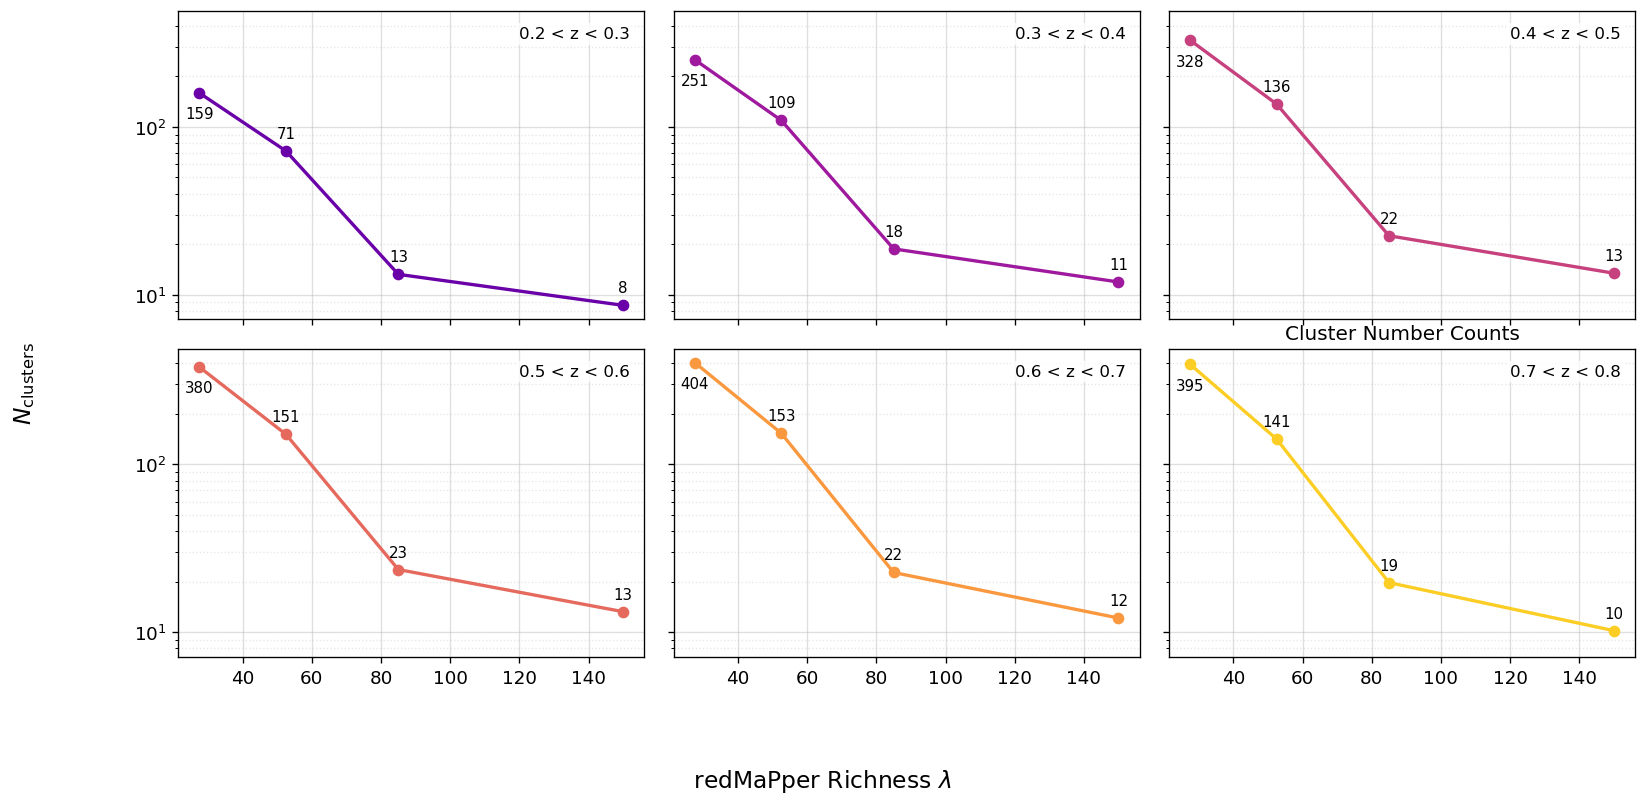

Total Clusters: 2871.9739999999997


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Compute richness bin centers ----------
rich_centers = 0.5 * (10**Rich_bins[:, 0] + 10**Rich_bins[:, 1])

# ---------- Use data-driven dimensions ----------
n_z = counts_data.shape[0]
n_r = counts_data.shape[1]

# Redshift labels (USE THESE, not Z_bins)
z_bin_label = ["0.2 < z < 0.3", "0.3 < z < 0.4", "0.4 < z < 0.5",
               "0.5 < z < 0.6", "0.6 < z < 0.7", "0.7 < z < 0.8"]

# ---------- Global style ----------
plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 13,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 120
})

# ---------- Layout ----------
ncols = 3
nrows = int(np.ceil(n_z / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 7), sharex=True, sharey=True)
axes = axes.flatten()

# ---------- Colors ----------
colors = plt.cm.plasma(np.linspace(0.2, 0.9, n_z))  # nicer than viridis for contrast

# ---------- Plot loop ----------
for i in range(n_z):
    ax = axes[i]

    y = counts_data[i, :]

    ax.plot(
        rich_centers,
        y,
        marker='o',
        linestyle='-',
        linewidth=2,
        markersize=6,
        color=colors[i]
    )

    # ---------- Annotate each point ----------
    ymax = np.max(y)
    
    for x, val in zip(rich_centers, y):
        if val > 0:
            # If close to top → place label BELOW
            if val > 0.7 * ymax:
                offset = (0, -8)
                va = 'top'
            else:
                offset = (0, 6)
                va = 'bottom'
    
            ax.annotate(
                f"{int(val)}",
                (x, val),
                textcoords="offset points",
                xytext=offset,
                ha='center',
                va=va,
                fontsize=9
            )

    # ---------- Log scale ----------
    ax.set_yscale("log")

    # ---------- Grid ----------
    ax.grid(True, which='major', linestyle='-', alpha=0.4)
    ax.grid(True, which='minor', linestyle=':', alpha=0.3)

    # ---------- Panel label ----------
    ax.text(
        0.97, 0.95,
        z_bin_label[i],
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2)
    )

# ---------- Hide unused panels ----------
for j in range(n_z, len(axes)):
    axes[j].axis('off')

# ---------- Shared labels ----------
fig.supxlabel(r" redMaPper Richness $\lambda$", fontsize=14)
fig.supylabel(r"$N_{\mathrm{clusters}}$", fontsize=14)

# ---------- Layout ----------
plt.tight_layout(rect=[0.05, 0.05, 1, 0.97])
plt.title("Cluster Number Counts")
# ---------- Save ----------

plt.show()

print(f"Total Clusters: {np.sum(counts_data.flatten())}")

## Prediction fiducial

In [4]:

from crow import ClusterShearProfile
from crow import ClusterAbundance
from crow.recipes.binned_exact import ExactBinnedClusterRecipe
from crow.recipes.binned_grid import GridBinnedClusterRecipe
from crow import completeness_models, mass_proxy, purity_models, kernel
from crow.properties import ClusterProperty

mass_richness_unb = mass_proxy.MurataUnbinned(pivot_log_mass=14.3, pivot_redshift=0.5)
mass_richness_unb.parameters["mu0"] = 3.34
mass_richness_unb.parameters["mu1"] = 2.3/np.log(10)
mass_richness_unb.parameters["mu2"] = 0.0
mass_richness_unb.parameters["sigma0"] = 0.56
mass_richness_unb.parameters["sigma1"] =0.0
mass_richness_unb.parameters["sigma2"] = 0.0





hmf = ccl.halos.MassFuncDespali16(mass_def="200c")
cosmo = ccl.Cosmology(
    Omega_c= 0.22,
    Omega_b=0.0448,
    h=0.71,
    n_s=0.963,
    sigma8=	0.8,
    w0=-1.0,
    wa=0.0,
    transfer_function="boltzmann_camb"
)

mass_grid_size = 500
redshift_grid_size = 50
proxy_grid_size = 50
sky_area =  436.6

mass_interval = (12.5, 16.0)


cl_abundandce = ClusterAbundance(cosmo, hmf)
cl_delta_sigma = ClusterShearProfile(
    cosmo, hmf, is_delta_sigma=True, cluster_concentration=3.8
)
redshift_distribution = kernel.SpectroscopicRedshift()


In [8]:
recipe_grid_abundance = GridBinnedClusterRecipe(
    mass_interval=mass_interval,
    cluster_theory=cl_abundandce,
    redshift_distribution=redshift_distribution,
    mass_distribution=mass_richness_unb,
    proxy_grid_size=proxy_grid_size,
    redshift_grid_size=redshift_grid_size,
    mass_grid_size=mass_grid_size,
    purity=None,
    completeness=None
)

recipe_grid_shear = GridBinnedClusterRecipe(
    mass_interval=mass_interval,
    cluster_theory=cl_delta_sigma,
    redshift_distribution=redshift_distribution,
    mass_distribution=mass_richness_unb,
    proxy_grid_size=proxy_grid_size,
    redshift_grid_size=redshift_grid_size,
    mass_grid_size=mass_grid_size,
    purity=None,
    completeness=None
)

recipe_grid_abundance.setup()
recipe_grid_shear.setup()

grid_counts_vals  = np.zeros((len(Z_bins), len(Rich_bins)))
grid_shear_vals  = np.zeros((len(Z_bins), len(Rich_bins), len(Radius_bins)))

for i, zb in enumerate(Z_bins):
    for j, pb in enumerate(Rich_bins):
        print(f"Redshift x Log10 Richness bins: {zb, pb}")
        val_counts = recipe_grid_abundance.evaluate_theory_prediction_counts(np.array(zb), np.array(pb), sky_area)
        grid_counts_vals[i,j] = val_counts
        shear_vals = recipe_grid_shear.evaluate_theory_prediction_lensing_profile(np.array(zb), np.array(pb), np.array(Radius_bins), sky_area, ClusterProperty.DELTASIGMA) / val_counts
        grid_shear_vals[i,j, :] = shear_vals



print(f"Theoretical Counts: {grid_counts_vals}")
print(f"Theoretical Shear: {grid_shear_vals}")

Redshift x Log10 Richness bins: (array([0.2, 0.3]), array([1.30103   , 1.54406804]))
Redshift x Log10 Richness bins: (array([0.2, 0.3]), array([1.54406804, 1.84509804]))
Redshift x Log10 Richness bins: (array([0.2, 0.3]), array([1.84509804, 2.        ]))
Redshift x Log10 Richness bins: (array([0.2, 0.3]), array([2.     , 2.30103]))
Redshift x Log10 Richness bins: (array([0.3, 0.4]), array([1.30103   , 1.54406804]))
Redshift x Log10 Richness bins: (array([0.3, 0.4]), array([1.54406804, 1.84509804]))
Redshift x Log10 Richness bins: (array([0.3, 0.4]), array([1.84509804, 2.        ]))
Redshift x Log10 Richness bins: (array([0.3, 0.4]), array([2.     , 2.30103]))
Redshift x Log10 Richness bins: (array([0.4, 0.5]), array([1.30103   , 1.54406804]))
Redshift x Log10 Richness bins: (array([0.4, 0.5]), array([1.54406804, 1.84509804]))
Redshift x Log10 Richness bins: (array([0.4, 0.5]), array([1.84509804, 2.        ]))
Redshift x Log10 Richness bins: (array([0.4, 0.5]), array([2.     , 2.30103])

In [9]:
rel_error_matrix = np.abs(1 - grid_counts_vals / counts_data)
n_i, n_j = rel_error_matrix.shape


## Final plots

In [10]:
# counts_mean_data / shear_mean_data: aliases for the mean-data-vector arrays
# already loaded above, kept for compatibility with the plotting cells below.
counts_mean_data = counts_data
shear_mean_data = shear_data

print("Mean-vector counts:\n", counts_mean_data)
print("Mean-vector shear shape:", shear_mean_data.shape)


Mean-vector counts:
 [[159.01   71.804  13.212   8.635]
 [251.152 109.299  18.736  11.895]
 [328.289 136.724  22.437  13.423]
 [380.092 151.086  23.633  13.255]
 [404.329 153.386  22.694  12.152]
 [395.023 141.736  19.754  10.218]]
Mean-vector shear shape: (6, 4, 7)


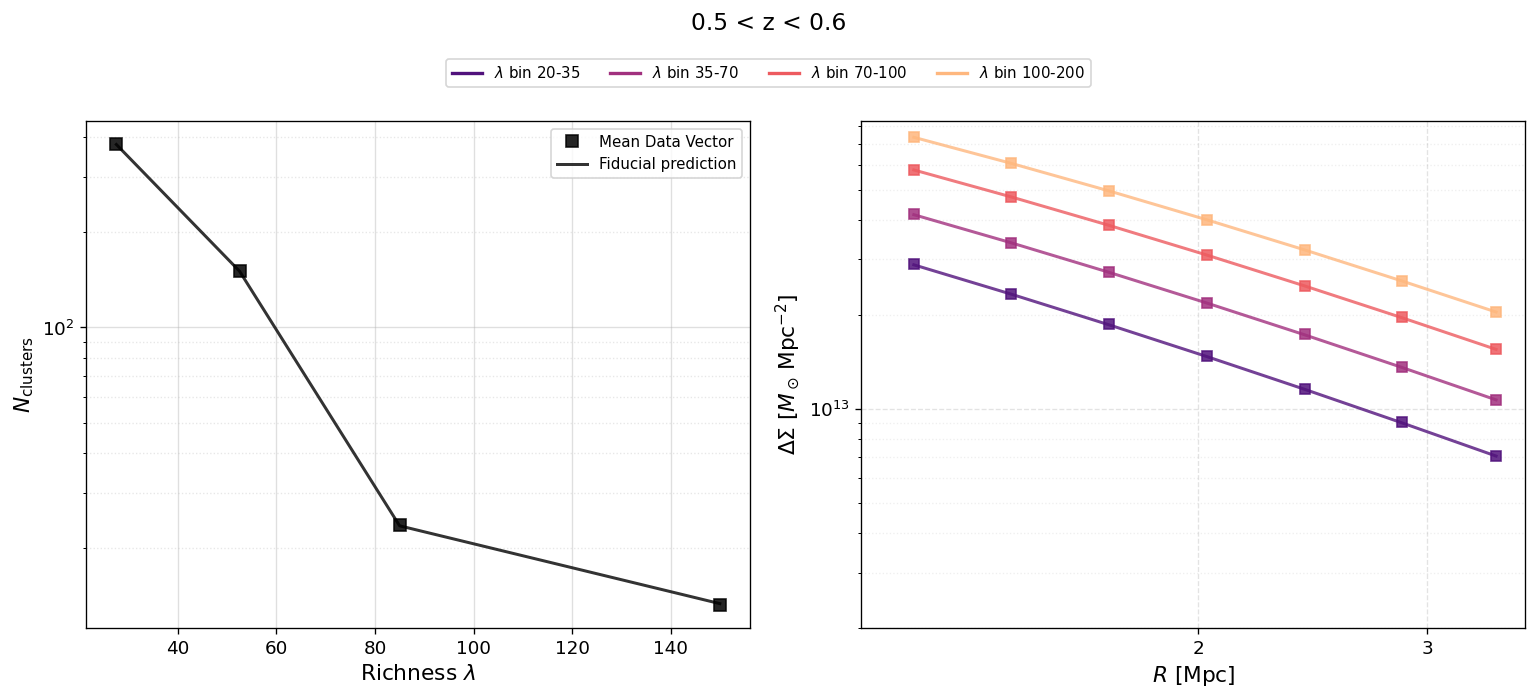

0/168 points above 2%
Fraction above 2%: 0.00%
Max error: 1.11%
Mean error: 0.33%
Number above 2%: 0
Indices:
[]
Errors:
[]


In [11]:
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

z_idx = 3  # 0.5 < z < 0.6
rich_colors = plt.cm.magma(np.linspace(0.25, 0.85, n_r))

plt.rcParams.update({"font.size": 13, "axes.labelsize": 13, "axes.titlesize": 13,
                      "xtick.labelsize": 11, "ytick.labelsize": 11, "figure.dpi": 120})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# ---------------- Counts panel ----------------
ax1.plot(rich_centers, counts_mean_data[z_idx, :], marker="s", linestyle="none",
         markersize=7, markerfacecolor="black", markeredgecolor="black",
         alpha=0.85, label="Mean Data Vector", zorder=3)
ax1.plot(rich_centers, grid_counts_vals[z_idx, :], linestyle="-", linewidth=1.8,
         color="black", alpha=0.8, label="Fiducial prediction", zorder=2)

ax1.set_yscale("log")
ax1.set_xlabel(r"Richness $\lambda$")
ax1.set_ylabel(r"$N_{\mathrm{clusters}}$")
ax1.grid(True, which="major", linestyle="-", alpha=0.4)
ax1.grid(True, which="minor", linestyle=":", alpha=0.3)
ax1.legend(fontsize=9, frameon=True, loc="best")

# ---------------- Lensing panel ----------------
for j in range(n_r):
    color = rich_colors[j]

    ax2.plot(Radius_bins, shear_mean_data[z_idx, j, :], marker="s", linestyle="none",
             markersize=6, markerfacecolor=color, markeredgecolor=color,
             alpha=0.85, zorder=4)

    ax2.plot(Radius_bins, grid_shear_vals[z_idx, j, :], linestyle="-", color=color,
             linewidth=1.8, alpha=0.8, zorder=3)

ax2.set_xscale("log"); ax2.set_yscale("log")
ax2.set_xlim(left=1.1); ax2.set_ylim(bottom=2e12)
ax2.set_xlabel(r"$R\ [\mathrm{Mpc}]$")
ax2.set_ylabel(r"$\Delta\Sigma\ [M_\odot\,\mathrm{Mpc}^{-2}]$")
ax2.grid(True, which="major", linestyle="--", alpha=0.35)
ax2.grid(True, which="minor", linestyle=":", alpha=0.2)
ax2.xaxis.set_major_locator(mticker.FixedLocator([1, 2, 3, 4]))
ax2.xaxis.set_minor_locator(mticker.NullLocator())
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:g}"))

fig.suptitle(z_bin_label[z_idx], fontsize=14, y=1.06)

# ---------------- Richness-bin legend (still separate, above the figure) ----------------
rich_handles = [Line2D([0], [0], color=rich_colors[j], lw=2,
                        label=rf"$\lambda$ bin {rich_bin_label[j]}") for j in range(n_r)]
fig.legend(handles=rich_handles, loc="upper center",
           bbox_to_anchor=(0.5, 1.0), ncol=n_r, fontsize=9, frameon=True)

plt.tight_layout()
plt.savefig("./figures/counts_shear_capish_z0.5_0.6.pdf", dpi=300, bbox_inches="tight")
plt.show()
rel_error = np.abs(shear_mean_data / grid_shear_vals - 1.0)

n_above_2pct = np.sum(rel_error > 0.02)
n_total = rel_error.size
fraction_above_2pct = n_above_2pct / n_total

print(f"{n_above_2pct}/{n_total} points above 2%")
print(f"Fraction above 2%: {fraction_above_2pct:.2%}")
print(f"Max error: {np.max(rel_error):.2%}")
print(f"Mean error: {np.mean(rel_error):.2%}")
indices = np.argwhere(rel_error > 0.02)

print("Number above 2%:", len(indices))
print("Indices:")
print(indices)
print("Errors:")
print(rel_error[rel_error > 0.02])


In [12]:
# chi^2 / N for data vs fiducial prediction
data = np.asarray(counts_data, dtype=float)
model = np.asarray(grid_counts_vals, dtype=float)
err = np.asarray(counts_err, dtype=float)

mask = np.isfinite(data) & np.isfinite(model) & np.isfinite(err) & (err > 0)

chi2 = np.sum(((data[mask] - model[mask]) / err[mask])**2)
N = np.sum(mask)

print(f"chi2 = {chi2:.3f}")
print(f"N = {N}")
print(f"chi2 / N = {chi2 / N:.3f}")

chi2 = 0.174
N = 24
chi2 / N = 0.007


In [13]:
# chi^2 / N for shear data vs fiducial prediction
data = np.asarray(shear_data, dtype=float)
model = np.asarray(grid_shear_vals, dtype=float)
err = np.asarray(shear_err, dtype=float)

mask = np.isfinite(data) & np.isfinite(model) & np.isfinite(err) & (err > 0)

chi2 = np.sum(((data[mask] - model[mask]) / err[mask])**2)
N = np.sum(mask)

print(f"chi2 = {chi2:.3f}")
print(f"N = {N}")
print(f"chi2 / N = {chi2 / N:.3f}")

chi2 = 1.338
N = 168
chi2 / N = 0.008


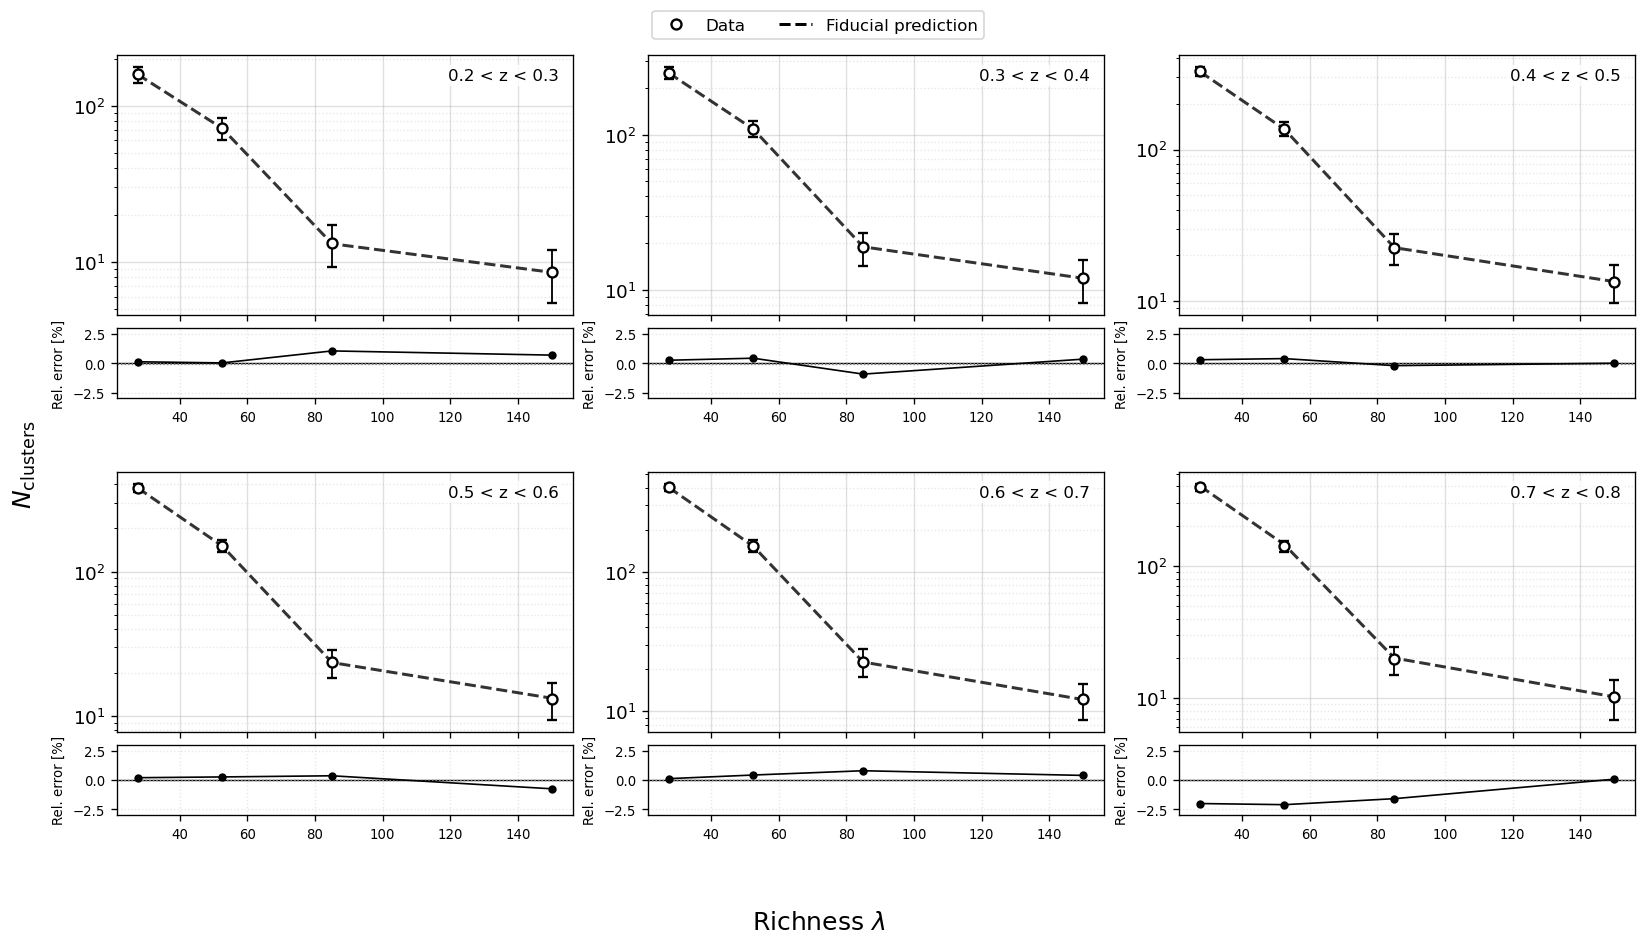

In [14]:
from matplotlib.lines import Line2D

ncols = 3
nrows = int(np.ceil(n_z / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(14, 8),
    sharex=True
)
axes = np.atleast_1d(axes).flatten()

for i in range(n_z):
    ax = axes[i]
    y_data = counts_mean_data[i, :]
    y_model = grid_counts_vals[i, :]

    # Main plot
    ax.errorbar(
        rich_centers, y_data, yerr=counts_err[i, :],
        fmt="o", color="black",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.4,
        markersize=6,
        capsize=3,
        elinewidth=1.1,
        linestyle="none",
        zorder=4
    )

    ax.plot(
        rich_centers, y_model,
        linestyle="--",
        linewidth=1.8,
        color="black",
        alpha=0.8,
        zorder=2
    )

    ax.set_yscale("log")
    ax.grid(True, which="major", linestyle="-", alpha=0.4)
    ax.grid(True, which="minor", linestyle=":", alpha=0.3)

    ax.text(
        0.97, 0.95, z_bin_label[i],
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2)
    )

    # Relative error
    rel_error = y_data / y_model - 1.0

    # Zero line
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)

    # Plot relative error on same panel for now
    # (see note below for true subaxes)
    ax2 = ax.inset_axes([0.0, -0.32, 1.0, 0.27])

    ax2.axhline(0, color="black", linewidth=0.8)
    ax2.axhline(0.02, color="gray", linestyle=":", linewidth=0.8)
    ax2.axhline(-0.02, color="gray", linestyle=":", linewidth=0.8)

    ax2.plot(
        rich_centers,
        rel_error * 100,
        "o-",
        color="black",
        markersize=4,
        linewidth=1.0
    )

    ax2.set_ylabel("Rel. error [%]", fontsize=8)
    ax2.grid(True, linestyle=":", alpha=0.3)
    ax2.set_ylim(-3, 3)

    ax2.tick_params(axis="both", labelsize=8)

for j in range(n_z, nrows * ncols):
    axes[j].axis("off")

fig.supxlabel(r"Richness $\lambda$", fontsize=15)
fig.supylabel(r"$N_{\mathrm{clusters}}$", fontsize=15)

style_handles = [
    Line2D(
        [0], [0],
        color="black",
        marker="o",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.4,
        linestyle="none",
        markersize=6,
        label="Data"
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle="--",
        lw=1.8,
        label="Fiducial prediction"
    ),
]

fig.legend(
    handles=style_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=2,
    fontsize=10,
    frameon=True
)

plt.tight_layout(rect=[0.008, 0.008, 1, 0.95])
plt.show()


In [15]:
counts_std_full = counts_err  # (n_z, n_rich)
mask_full = counts_std_full > 0

chi2_total = np.sum(
    ((counts_mean[mask_full] - grid_counts_vals[mask_full])
     / (counts_std_full[mask_full] / np.sqrt(n_seeds)))**2
)
dof_total = np.sum(mask_full)
print(f"TOTAL chi2/dof = {chi2_total/dof_total:.3f}  (N={dof_total})")
print()

for i, z_bin in enumerate(Z_bins):
    counts_std_i = counts_std_full[i, :]
    mask_i = counts_std_i > 0
    chi2_i = np.sum(
        ((counts_mean[i, mask_i] - grid_counts_vals[i, mask_i])
         / (counts_std_i[mask_i] / np.sqrt(n_seeds)))**2
    )
    dof_i = np.sum(mask_i)
    print(f"{z_bin[0]:.1f} < z < {z_bin[1]:.1f}:  chi2/dof = {chi2_i/dof_i:.3f}  (N={dof_i})")


mask_5 = counts_std_full[:5, :] > 0
chi2_5 = np.sum(
    ((counts_mean[:5][mask_5] - grid_counts_vals[:5][mask_5])
     / (counts_std_full[:5][mask_5] / np.sqrt(n_seeds)))**2
)
dof_5 = np.sum(mask_5)
print(f"0.2-0.7 (5 bins) chi2/dof = {chi2_5/dof_5:.3f}  (N={dof_5})")

for i in range(5):
    std_i = counts_std_full[i, :]
    m = std_i > 0
    c2 = np.sum(((counts_mean[i, m] - grid_counts_vals[i, m]) / (std_i[m]/np.sqrt(n_seeds)))**2)
    print(f"  {Z_bins[i][0]:.1f}<z<{Z_bins[i][1]:.1f}: chi2/dof = {c2/np.sum(m):.3f}")


TOTAL chi2/dof = 7.245  (N=24)

0.2 < z < 0.3:  chi2/dof = 0.427  (N=4)
0.3 < z < 0.4:  chi2/dof = 0.908  (N=4)
0.4 < z < 0.5:  chi2/dof = 0.829  (N=4)
0.5 < z < 0.6:  chi2/dof = 0.650  (N=4)
0.6 < z < 0.7:  chi2/dof = 0.911  (N=4)
0.7 < z < 0.8:  chi2/dof = 39.746  (N=4)
0.2-0.7 (5 bins) chi2/dof = 0.745  (N=20)
  0.2<z<0.3: chi2/dof = 0.427
  0.3<z<0.4: chi2/dof = 0.908
  0.4<z<0.5: chi2/dof = 0.829
  0.5<z<0.6: chi2/dof = 0.650
  0.6<z<0.7: chi2/dof = 0.911


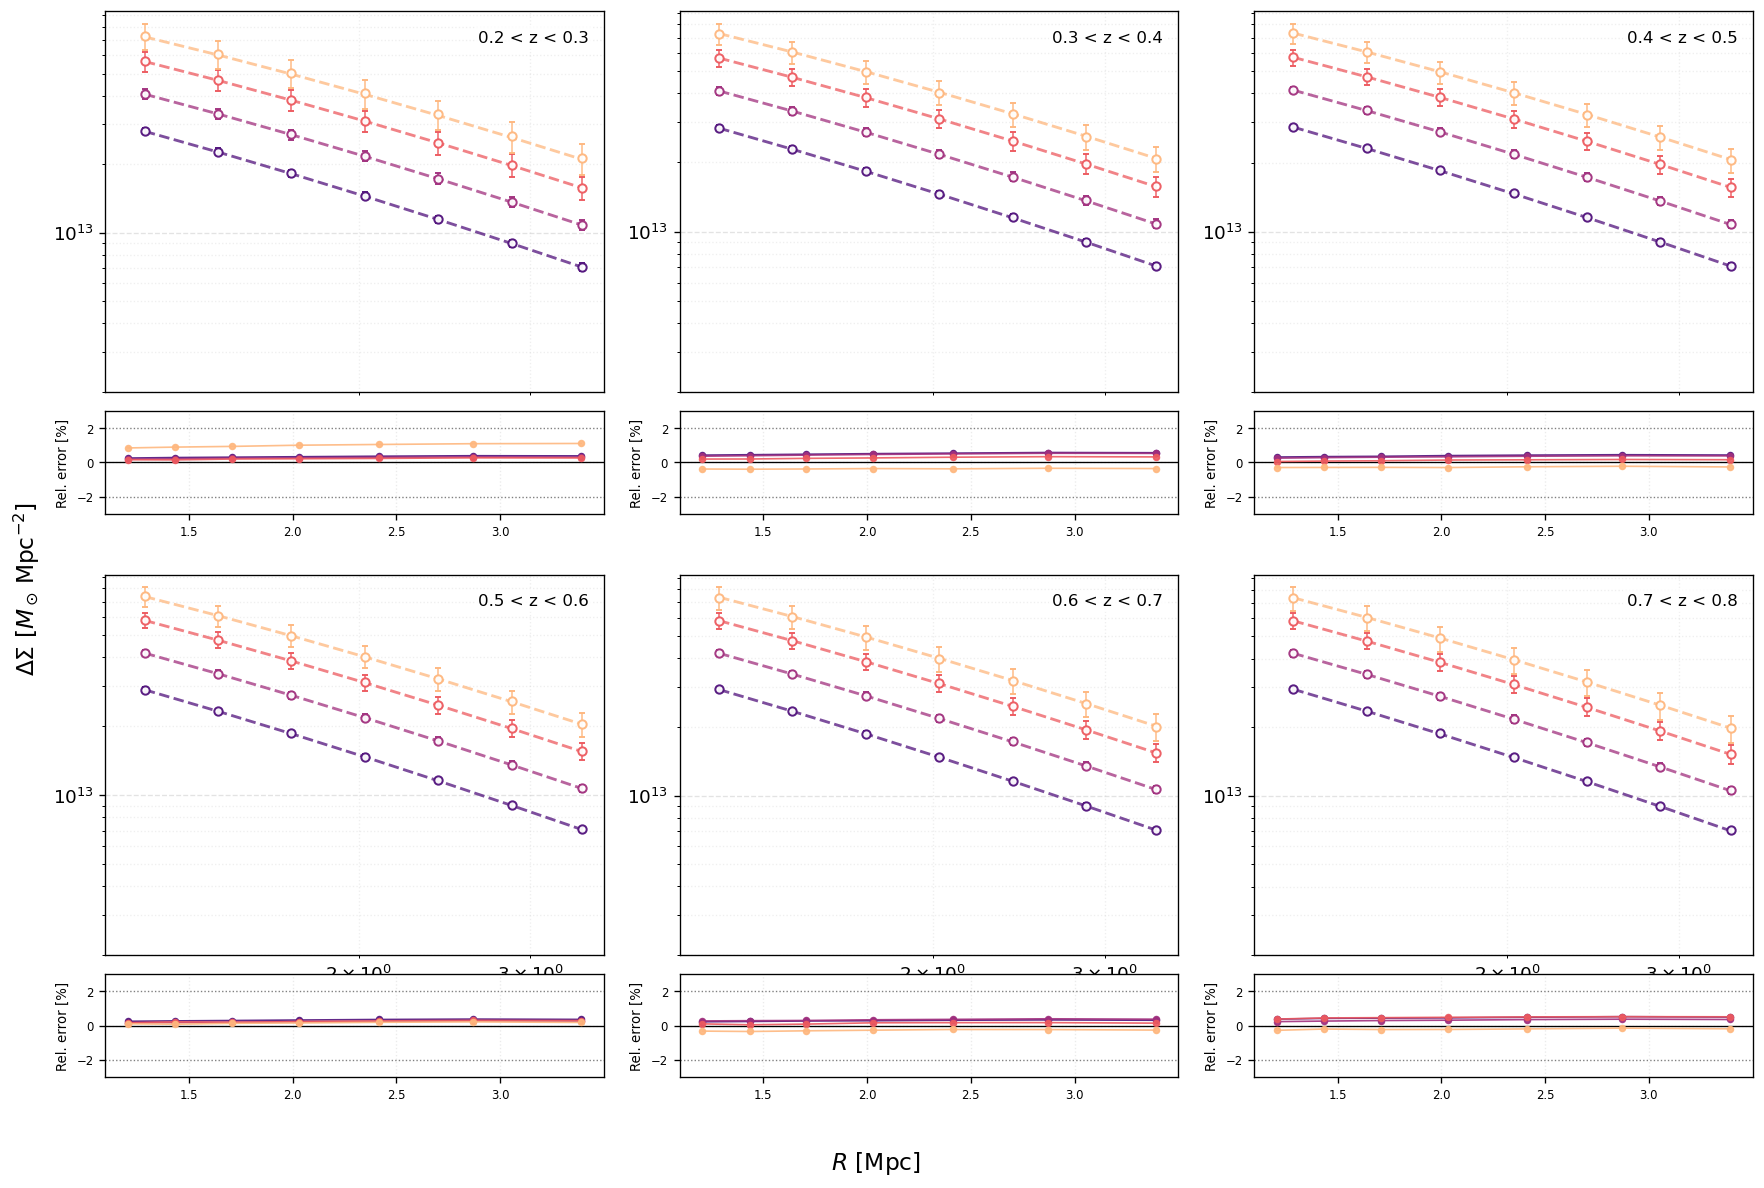

In [16]:
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(15, 10),
    sharex=True
)

axes = np.atleast_1d(axes).flatten()

for i in range(n_z):
    ax = axes[i]

    # ---------------------------------------------------------
    # Main ΔΣ plot
    # ---------------------------------------------------------
    for j in range(n_r):
        color = rich_colors[j]

        y_data = shear_mean_data[i, j, :]
        y_model = grid_shear_vals[i, j, :]

        ax.errorbar(
            Radius_bins,
            y_data,
            yerr=shear_err[i, j, :],
            fmt="o",
            color=color,
            markerfacecolor="white",
            markeredgecolor=color,
            markeredgewidth=1.2,
            markersize=5,
            elinewidth=0.9,
            capsize=2,
            linestyle="none",
            alpha=0.95,
            zorder=5
        )

        ax.plot(
            Radius_bins,
            y_model,
            linestyle="--",
            color=color,
            linewidth=1.7,
            alpha=0.75,
            zorder=3
        )

    # ---------------------------------------------------------
    # Relative-error inset
    # ---------------------------------------------------------
    ax2 = ax.inset_axes([0.0, -0.32, 1.0, 0.27])

    ax2.axhline(0, color="black", linewidth=0.8)
    ax2.axhline(2, color="gray", linestyle=":", linewidth=0.8)
    ax2.axhline(-2, color="gray", linestyle=":", linewidth=0.8)

    # Plot ALL richness bins in the same inset
    for j in range(n_r):
        color = rich_colors[j]

        y_data = shear_mean_data[i, j, :]
        y_model = grid_shear_vals[i, j, :]

        rel_error = y_data / y_model - 1.0

        ax2.plot(
            Radius_bins,
            100 * rel_error,
            "o-",
            color=color,
            markersize=3.5,
            linewidth=1.0,
            alpha=0.9
        )

    ax2.set_ylim(-3, 3)
    ax2.set_ylabel("Rel. error [%]", fontsize=8)
    ax2.grid(True, linestyle=":", alpha=0.25)
    ax2.tick_params(axis="both", labelsize=7)

    # ---------------------------------------------------------
    # Main plot formatting
    # ---------------------------------------------------------
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(left=1.1)
    ax.set_ylim(bottom=2e12)

    ax.grid(True, which="major", linestyle="--", alpha=0.35)
    ax.grid(True, which="minor", linestyle=":", alpha=0.2)

    ax.text(
        0.97, 0.95, z_bin_label[i],
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(
            facecolor="white",
            alpha=0.85,
            edgecolor="none",
            pad=2
        )
    )

# Turn off unused panels
for j in range(n_z, nrows * ncols):
    axes[j].axis("off")

fig.supxlabel(r"$R\ [\mathrm{Mpc}]$", fontsize=14)
fig.supylabel(r"$\Delta\Sigma\ [M_\odot\,\mathrm{Mpc}^{-2}]$", fontsize=14)

plt.tight_layout()
plt.show()

## Countour Plots

In [ ]:
import sys
sys.path.append("../../")
from clpipe.utils.cosmosis_mcmc_plots import plot_triangle, ChainStyle, PlotConfig, chains_to_fits, fits_to_samples


### Regenerate saved chain (optional -- see cell below)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Regenerating ./chains/capish_chains_cc_wl.fits now lives in its own script,
# outside Jupyter:
#
#     python save_chains.py
#
# Run it whenever the underlying raw chain changes (e.g. after a resume=T
# extension). Everyone else just loads the already-saved fits below --
# nothing to run in this notebook.
# ══════════════════════════════════════════════════════════════════════════════


In [ ]:
import numpy as np
import sys
sys.path.append("../../")
from clpipe.utils.cosmosis_mcmc_plots import plot_triangle, ChainStyle, PlotConfig, chains_to_fits, fits_to_samples

DIR = ["./run_in2p3_both_mean/outputs_both/output_rp/number_counts_samples.txt"]  # kept for the per-walker convergence cell below -- fits files don't preserve walker/step structure


FIDUCIALS = [
        (r"\Omega_c", 0.22),
        (r"\sigma_8", 0.80),
        (r"\mu_0", 3.34),
        (r"\mu_m", 2.3/np.log(10)),
        (r"\mu_z", 0.0),
        (r"\sigma_0", 0.56),
        (r"\sigma_m", 0.0),
        (r"\sigma_z", 0.0),
]


STYLES_3 = [
    ChainStyle(
        "Counts + Lensing Mean Mocks",
        filled=True,
        fill_alpha=0.7,
        linewidth=1.2,
        linestyle="-",
        color="#9C6ADE",
    )
]

# ── Config ────────────────────────────────────────────────────────────────────
cfg_8par = PlotConfig(figsize=8, output_dir="./figures", burn_fraction=0.15)

# ── Plot: load from saved (already burn-trimmed) ../../data/capish_simulation/chains/capish_chains_cc_wl.fits ─
samples_both = plot_triangle(samples=fits_to_samples(["../../data/capish_simulation/chains/capish_chains_cc_wl.fits"]),
                              params=FIDUCIALS, styles=STYLES_3, name="capish_redmapper",
                              config=cfg_8par, save=True)

# (regeneration in the dedicated cell above)


<class 'getdist.mcsamples.MCSamples'>
Number of samples in this MCSamples object: 1107400
Available parameter names: ['\\Omega_c', '\\sigma_8', '\\mu_0', '\\mu_m', '\\mu_z', '\\sigma_0', '\\sigma_m', '\\sigma_z']

Gelman-Rubin unavailable ('bool' object is not iterable) -- this MCSamples was likely loaded as one merged chain rather than one sub-chain per walker.

Marginalized posterior vs fiducial:
         \Omega_c: mean =   0.2290  std =  0.0240  fiducial =  0.220  |mean-fid|/std =  0.37
         \sigma_8: mean =   0.7951  std =  0.0337  fiducial =  0.800  |mean-fid|/std =  0.14
            \mu_0: mean =   3.3388  std =  0.2551  fiducial =  3.340  |mean-fid|/std =  0.00


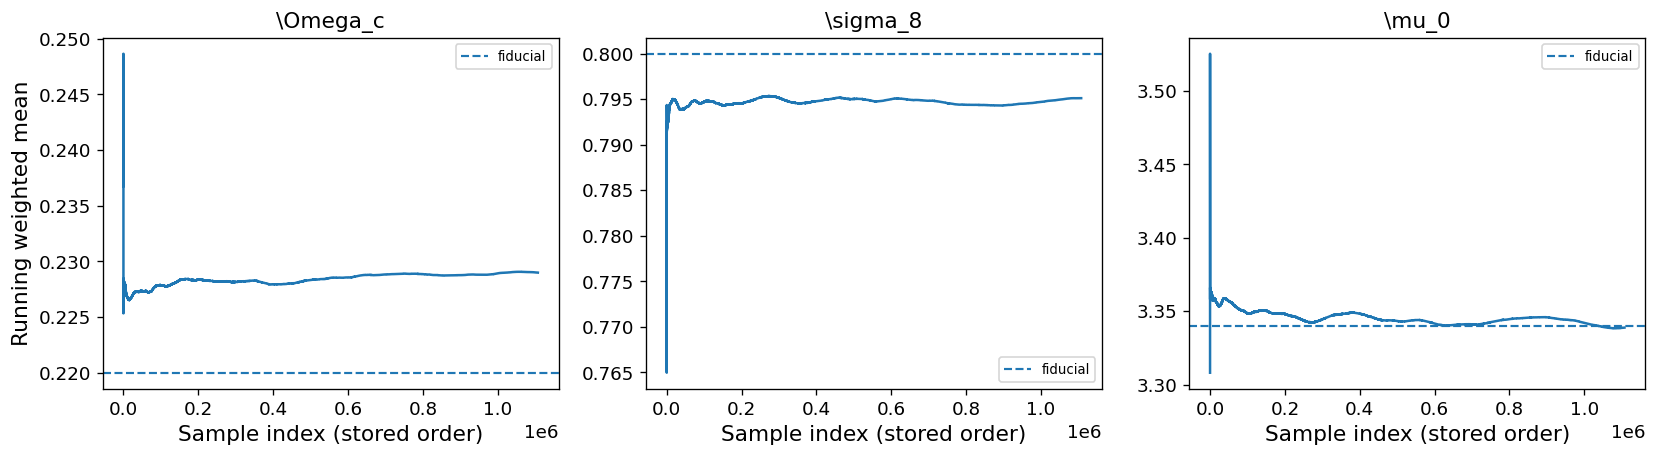

In [24]:
import matplotlib.pyplot as plt
# ------------------------------------------------------------
# Convergence check for Omega_c, sigma_8, mu_0
# using the MCSamples object(s) already built by plot_triangle
# above, instead of re-parsing the raw chain file.
# ------------------------------------------------------------

# plot_triangle returns a list of MCSamples (one per entry in DIR)
# when multiple dirs are given; be defensive about both cases.
samples_list = samples_both if isinstance(samples_both, (list, tuple)) else [samples_both]
samples = samples_list[0]  # single seed run -> only one chain

print(type(samples))
print("Number of samples in this MCSamples object:", samples.numrows)

# ---- Parameter name lookup ----
param_names_available = [p.name for p in samples.paramNames.names]
print("Available parameter names:", param_names_available)

def find_param(fragment):
    for p in samples.paramNames.names:
        if fragment.lower() in p.name.lower() or fragment.lower() in p.label.lower():
            return p.name
    raise ValueError(f"No parameter matching '{fragment}' found in {param_names_available}")

name_omega_c = find_param("omega_c")
name_sigma8  = find_param("sigma_8") if any("sigma_8" in n.lower() for n in param_names_available) else find_param("sigma8")
name_mu0     = find_param("mu_0") if any("mu_0" in n.lower() for n in param_names_available) else find_param("mu0")

fiducials_by_name = {name_omega_c: 0.22, name_sigma8: 0.80, name_mu0: 3.34}

# ---- 1. Marginalized stats vs fiducial ----
# (Gelman-Rubin dropped: this MCSamples is loaded from the saved fits as one
# merged chain, not one sub-chain per walker, so it never succeeds here --
# see convergence_diagnostics.py for real per-walker autocorrelation-time
# convergence checks, sourced from the same saved fits via fits_to_walker_chain.)
stats = samples.getMargeStats()
print("\nMarginalized posterior vs fiducial:")
for pname, fid in fiducials_by_name.items():
    par = stats.parWithName(pname)
    print(f"  {pname:>15}: mean = {par.mean:8.4f}  std = {par.err:7.4f}  "
          f"fiducial = {fid:6.3f}  |mean-fid|/std = {abs(par.mean - fid)/par.err:5.2f}")

# ---- 3. Running mean along the stored sample order (proxy for "settled",
#         not a true per-walker trace) ----
fig, axes = plt.subplots(1, len(fiducials_by_name), figsize=(14, 4))
pars = samples.getParams()
weights = samples.weights

for ax, (pname, fid) in zip(axes, fiducials_by_name.items()):
    values = getattr(pars, pname)
    running_mean = np.cumsum(values * weights) / np.cumsum(weights)
    ax.plot(running_mean)
    ax.axhline(fid, color="tab:blue", linestyle="--", linewidth=1.3, label="fiducial")
    ax.set_title(pname)
    ax.set_xlabel("Sample index (stored order)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Running weighted mean")
plt.tight_layout()
plt.show()

Columns -> cosmological_parameters--omega_c cosmological_parameters--sigma_8 firecrown_number_counts--mass_distribution_mu0


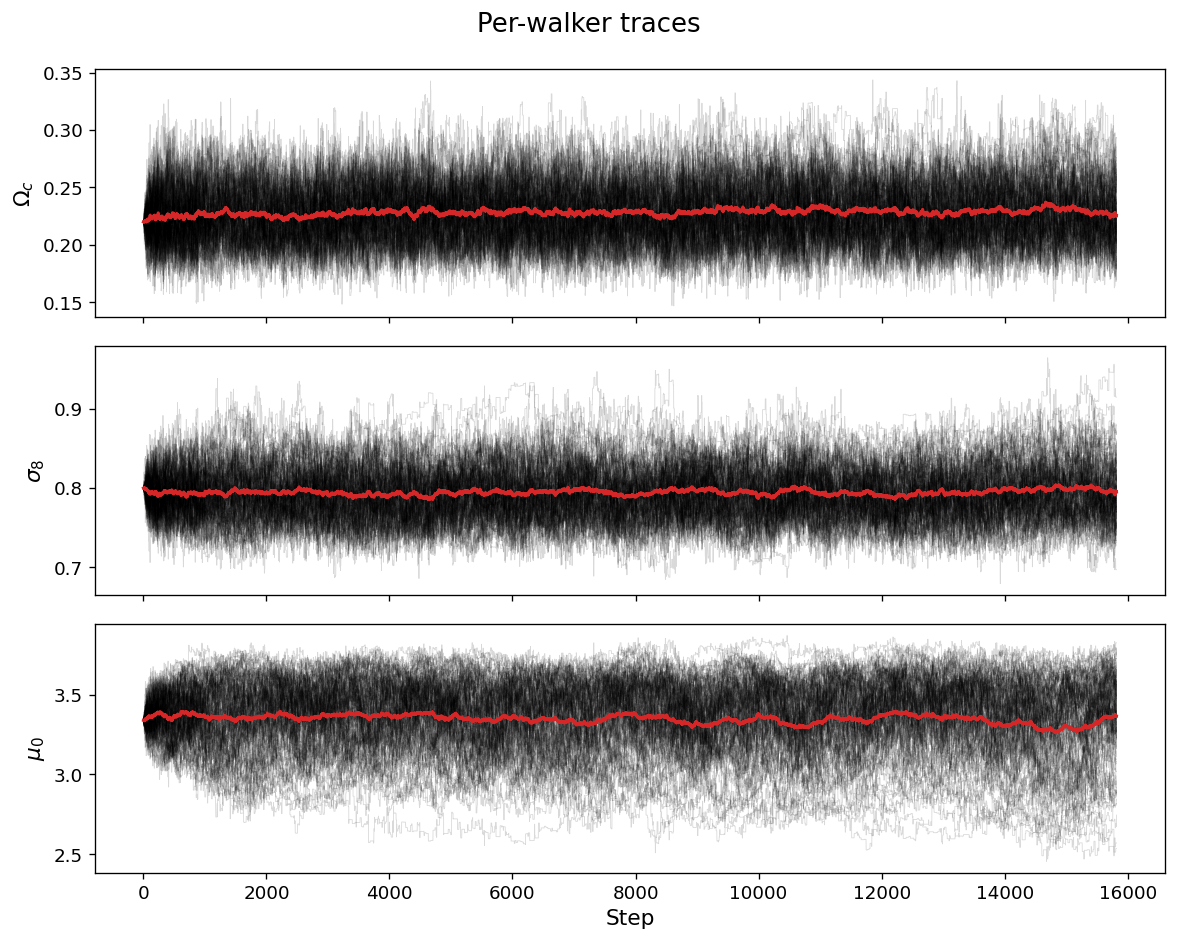


       param      tau     N_eff   1st half   2nd half  diff/sigma
  $\Omega_c$    379.7      2083     0.2272     0.2293        2.88
  $\sigma_8$    583.6      1355     0.7940     0.7952        0.97
     $\mu_0$    800.9       988     3.3583     3.3359        2.04


In [25]:
import emcee

chain_path = DIR[0]
N_WALKERS = 100

# ---- Column header is the FIRST line of the file ----
with open(chain_path) as f:
    header_line = f.readline()
if not header_line.startswith("#"):
    raise RuntimeError(f"Expected a '#'-prefixed header on line 1, got: {header_line[:80]!r}")
col_names = header_line.lstrip("#").split()

def find_col(patterns):
    for i, name in enumerate(col_names):
        if any(p in name.lower() for p in patterns):
            return i
    raise ValueError(f"Could not find a column matching {patterns} in {col_names}")

idx_omega_c = find_col(["omega_c"])
idx_sigma8  = find_col(["sigma_8", "sigma8"])
idx_mu0     = find_col(["mu_0", "mu0"])
print("Columns ->", col_names[idx_omega_c], col_names[idx_sigma8], col_names[idx_mu0])

raw = np.loadtxt(chain_path)  # already skips every '#' line, header + trailing metadata
n_total = raw.shape[0]
if n_total % N_WALKERS != 0:
    remainder = n_total % N_WALKERS
    raw = raw[remainder:]
    print(f"Trimmed {remainder} rows to divide evenly by N_WALKERS.")

n_steps = raw.shape[0] // N_WALKERS
chain = raw.reshape(n_steps, N_WALKERS, -1)  # (step, walker, param)

params_to_check = {r"$\Omega_c$": idx_omega_c, r"$\sigma_8$": idx_sigma8, r"$\mu_0$": idx_mu0}

# ---- Per-walker trace plot (the real gold-standard check) ----
fig, axes = plt.subplots(len(params_to_check), 1, figsize=(10, 8), sharex=True)
for ax, (label, idx) in zip(axes, params_to_check.items()):
    ax.plot(chain[:, :, idx], color="k", alpha=0.15, linewidth=0.5)
    ax.plot(chain[:, :, idx].mean(axis=1), color="tab:red", linewidth=1.8)
    ax.set_ylabel(label)
axes[-1].set_xlabel("Step")
fig.suptitle("Per-walker traces")
plt.tight_layout()
plt.show()

# ---- Autocorrelation-corrected split-half test ----
half = n_steps // 2
print(f"\n{'param':>12} {'tau':>8} {'N_eff':>9} {'1st half':>10} {'2nd half':>10} {'diff/sigma':>11}")
for label, idx in params_to_check.items():
    sub = chain[:, :, idx]
    try:
        tau = emcee.autocorr.integrated_time(sub, tol=0)[0]
    except emcee.autocorr.AutocorrError:
        tau = n_steps / 10  # crude fallback if the estimate is unreliable
    n_eff_half = (half * N_WALKERS) / tau

    m1, m2 = sub[:half].mean(), sub[half:].mean()
    s1, s2 = sub[:half].std(), sub[half:].std()
    se1, se2 = s1 / np.sqrt(n_eff_half), s2 / np.sqrt(n_eff_half)
    diff_sigma = abs(m1 - m2) / np.sqrt(se1**2 + se2**2)

    print(f"{label:>12} {tau:8.1f} {n_eff_half:9.0f} {m1:10.4f} {m2:10.4f} {diff_sigma:11.2f}")

In [26]:
import numpy as np
from astropy.io import fits

# Read saved Capish chain
filename = "../../data/capish_simulation/chains/capish_chains_cc_wl.fits"

with fits.open(filename) as hdul:
    data = hdul[1].data

# Get parameter names
print(data.columns.names)

fid = {
    "Omega_c": 0.22,
    "sigma_8": 0.80,
    "mu_0": 3.34,
    "mu_m": 0.99,
    "mu_z": 0.0,
    "sigma_0": 0.56,
    "sigma_m": 0.0,
    "sigma_z": 0.0,
}

# Compute posterior mean, std, and tension
for par, fid_value in fid.items():

    samples = data[par]

    mean = np.mean(samples)
    sigma = np.std(samples)

    tension = (mean - fid_value) / sigma

    print(
        f"{par:10s} "
        f"mean = {mean:.5f}, "
        f"sigma = {sigma:.5f}, "
        f"fid = {fid_value:.5f}, "
        f"tension = {tension:.2f} sigma"
    )

['Omega_c', 'sigma_8', 'mu_0', 'mu_m', 'mu_z', 'sigma_0', 'sigma_m', 'sigma_z']
Omega_c    mean = 0.22899, sigma = 0.02401, fid = 0.22000, tension = 0.37 sigma
sigma_8    mean = 0.79512, sigma = 0.03370, fid = 0.80000, tension = -0.14 sigma
mu_0       mean = 3.33882, sigma = 0.25513, fid = 3.34000, tension = -0.00 sigma
mu_m       mean = 1.02167, sigma = 0.06278, fid = 0.99000, tension = 0.50 sigma
mu_z       mean = 0.05870, sigma = 0.25716, fid = 0.00000, tension = 0.23 sigma
sigma_0    mean = 0.54351, sigma = 0.11546, fid = 0.56000, tension = -0.14 sigma
sigma_m    mean = 0.00001, sigma = 0.05287, fid = 0.00000, tension = 0.00 sigma
sigma_z    mean = -0.00679, sigma = 0.17706, fid = 0.00000, tension = -0.04 sigma
